# Observer–Target Tracking Alignment
## Continuous Time-Series Cross-Correlation & Group-Level Statistics

**Repository:** [github.com/mooceanstudio/observer-target-tracking-analysis](https://github.com/mooceanstudio/observer-target-tracking-analysis)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mooceanstudio/observer-target-tracking-analysis/blob/main/tracking_crosscorr_analysis.ipynb)

> ⚠️ **This is a demonstration on SIMULATED (sample) data — not the study's real data.** The dataset is generated in Section 3 to match the study design exactly (28 observers, 6 trials, 1000 ms sampling) so the full pipeline can be shown working end-to-end. All numerical results below describe the simulated data only. See "Data used in this demonstration" for why simulation makes the pipeline *more* verifiable, and Section 12 for how the real tracking files drop in.

**End-to-end pipeline** implementing the project brief:

| Tier | Analysis | Output |
|---|---|---|
| **1** | Zero-lag Pearson *r* (baseline alignment) | 168 baseline values |
| **2** | Time-lagged cross-correlation, **−5 s … +10 s** in **1000 ms steps** (exactly **16 lags/session**, boundary rows **omitted, never zero-filled**) | 168 × 16 = **2,688** correlations → **Peak r** + **Peak lag** per session |
| **3** | Group-level inferential model (Mixed-Design ANOVA + complementary LMM), Test vs. Control | *F*, *df*, exact *p* |

### Data used in this demonstration

This notebook runs on **simulated data with known ground truth**, generated to match the study design exactly (28 observers: 15 Test / 13 Control; 6 target trials of 1–2 min; one sample per 1000 ms). Simulating first is deliberate: because every simulated observer is assigned a hidden *true* lag, Section 8 can verify that the pipeline **recovers the injected ground truth** — a correctness guarantee real data cannot provide. The real tracking files drop into `data/raw/` with only the ingest cell adapted; Tiers 1–3 run unchanged.

### Scientific grounding of the simulation

The observer model reproduces documented properties of continuous-rating traces:

- **Reaction lag of 1–6 s** — empirical analyses of continuous emotion annotation show evaluators lag the stimulus by 1–6 s while they observe, appraise, and move the input device (Mariooryad & Busso, 2015, *IEEE Trans. Affective Computing*; Khorram et al., 2019). The brief's −5…+10 s search window comfortably brackets this documented range.
- **Smooth, inert traces** — real joystick/dial annotation streams (e.g., the CASE dataset; Sharma et al., 2019, *Scientific Data*) are low-pass-filtered by hand biomechanics, so the simulator smooths each observer trace.
- **Individual scale use** — annotators differ in gain and offset on the rating scale, so each simulated observer applies a personal gain and bias (Pearson correlation is invariant to these, but raw traces look realistic).

**Lag sign convention** — a **positive lag** means the observer **trails** the target: their trace best matches the target's trace from *k* seconds earlier.

*Runs in local Jupyter or Google Colab — cell 1 installs any missing dependency automatically. In Colab, generated files live in the session's working directory (`/content`).*

In [1]:
# ============================================================
# 0. DEPENDENCIES — install anything missing (Google Colab safe)
# ============================================================
# Colab ships numpy/pandas/scipy/statsmodels/matplotlib preinstalled;
# only pingouin usually needs installing. Locally, use:
#     pip install -r requirements.txt
import importlib.util, subprocess, sys

for pkg in ["pandas", "numpy", "scipy", "statsmodels", "matplotlib", "pingouin"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       check=True)
print("all dependencies available")

all dependencies available


In [2]:
# ============================================================
# 1. SETUP — imports, reproducibility, environment report
# ============================================================
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy
import statsmodels
import statsmodels.formula.api as smf
from IPython.display import display
from scipy import stats
from scipy.ndimage import gaussian_filter1d

RNG_SEED = 42                      # single fixed seed -> bit-identical reruns
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.width", 130)
pd.set_option("display.precision", 4)

# -- figure style: recessive grid, thin marks, colourblind-safe palette --
plt.rcParams.update({
    "figure.figsize": (9, 3.6), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.frameon": False,
})
C_TARGET, C_TEST, C_CONTROL = "#52514e", "#2a78d6", "#1baf7a"

for name, mod in [("numpy", np), ("pandas", pd), ("scipy", scipy),
                  ("statsmodels", statsmodels), ("pingouin", pg)]:
    print(f"{name:<12} {mod.__version__}")

numpy        2.5.1
pandas       3.0.3
scipy        1.18.0
statsmodels  0.14.6
pingouin     0.6.1


In [3]:
# ============================================================
# 2. STUDY CONFIGURATION (mirrors the project brief exactly)
# ============================================================
N_TEST, N_CONTROL = 15, 13                    # 28 observers total
N_TARGETS = 6                                 # 6 unique video trials
LAGS = list(range(-5, 11))                    # -5 ... +10 s inclusive
assert len(LAGS) == 16                        # exactly 16 lag steps per session

DATA_DIR = Path("data/raw")
OUT_DIR = Path("outputs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

observers = pd.DataFrame({
    "observer_id": [f"O{i:02d}" for i in range(1, N_TEST + N_CONTROL + 1)],
    "group": ["Test"] * N_TEST + ["Control"] * N_CONTROL,
})
target_ids = [f"T{j}" for j in range(1, N_TARGETS + 1)]
print(observers.groupby("group").size())

group
Control    13
Test       15
dtype: int64


## 3. Simulated raw data (stand-in for the study's tracking files)

Each **target** signal is a smoothed random walk rescaled to a 0–100 continuous rating scale, one row per 1000 ms, trial lengths 1–2 min. Each **observer** trace is generated as

$$\text{observer}(t) = \text{clip}_{[0,100]}\Big(\, \text{smooth}\big[\, g \cdot \text{target}(t - L) + b + \varepsilon(t) \,\big] \Big)$$

where $L$ is the observer's hidden **true reaction lag**, $g$ and $b$ a personal gain and bias, $\varepsilon$ rating noise, and *smooth* the biomechanical low-pass filter of hand-driven input.

Hidden ground truth (what Tier 3 should later detect):

| Group | True lag $L$ | Rating noise | Interpretation |
|---|---|---|---|
| **Test** (n = 15) | 1–3 s | low | fast, tight trackers |
| **Control** (n = 13) | 4–7 s | high | slow, noisy trackers |

Both lag ranges sit inside the empirically documented 1–6 s evaluator-lag band (Mariooryad & Busso, 2015), with the Control group pushed to its upper edge to create a detectable group difference.

In [4]:
# ============================================================
# 3. GENERATE SIMULATED RAW TRACKING FILES
# ============================================================
trial_lengths = rng.integers(60, 121, size=N_TARGETS)        # 1-2 min per brief

profiles = {}
for _, row in observers.iterrows():
    fast = row["group"] == "Test"
    profiles[row["observer_id"]] = {
        "true_lag": int(rng.integers(1, 4)) if fast else int(rng.integers(4, 8)),
        "noise_sd": 8.0 if fast else 16.0,
        "gain": float(rng.uniform(0.8, 1.2)),     # personal scale use
        "bias": float(rng.uniform(-8, 8)),
    }

def make_target_signal(n_seconds, rng):
    walk = np.cumsum(rng.normal(0, 1, n_seconds))
    smooth = gaussian_filter1d(walk, sigma=3)
    return 100 * (smooth - smooth.min()) / (smooth.max() - smooth.min())

def make_observer_trace(target, p, rng):
    delayed = pd.Series(target).shift(p["true_lag"]).bfill().to_numpy()
    raw = p["gain"] * delayed + p["bias"] + rng.normal(0, p["noise_sd"], len(target))
    return np.clip(gaussian_filter1d(raw, sigma=1.2), 0, 100)   # joystick inertia

for tid, n_sec in zip(target_ids, trial_lengths):
    df = pd.DataFrame({"time_s": np.arange(n_sec),
                       "target": make_target_signal(n_sec, rng)})
    for oid, p in profiles.items():
        df[oid] = make_observer_trace(df["target"].to_numpy(), p, rng)
    df.to_csv(DATA_DIR / f"{tid}.csv", index=False)

(pd.DataFrame(profiles).T.rename_axis("observer_id")
   .to_csv("data/synthetic_ground_truth.csv"))
print("Wrote raw trial files (trial lengths in s):",
      dict(zip(target_ids, trial_lengths.tolist())))

Wrote raw trial files (trial lengths in s): {'T1': 65, 'T2': 107, 'T3': 99, 'T4': 86, 'T5': 86, 'T6': 112}


In [5]:
# ============================================================
# 4. INGEST RAW TRACKING FILES into a repeatable environment
# ============================================================
trials = {tid: pd.read_csv(DATA_DIR / f"{tid}.csv") for tid in target_ids}
trials["T1"].iloc[:5, :6]     # preview: time, target, first observers

,time_s,target,O01,O02,O03,O04
0,0,95.4438,93.0865,100.0,93.1224,100.0
1,1,95.7585,96.5793,100.0,92.9148,100.0
2,2,96.3610,100.0000,100.0,92.1439,100.0
3,3,97.1882,100.0000,100.0,91.1992,100.0
4,4,98.1329,93.8383,100.0,91.4815,100.0


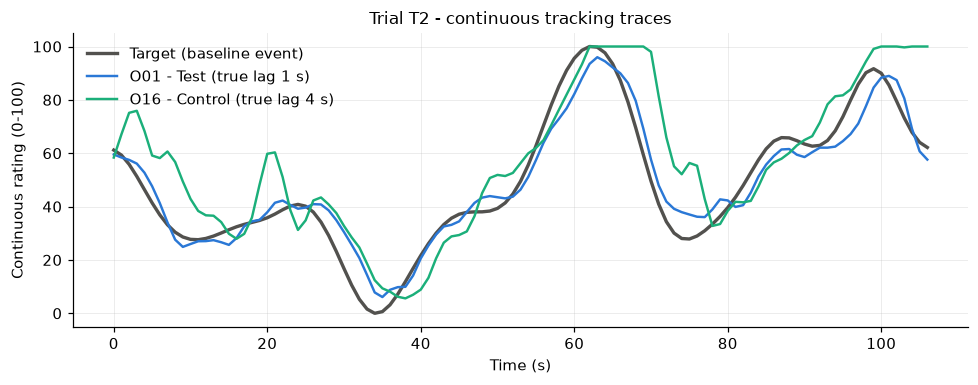

In [6]:
# --- Figure 1: what a tracking session looks like -----------------
# One Test observer visibly trails the target by ~2 s; one Control
# observer trails further and tracks more noisily.
t1 = trials["T2"]
fig, ax = plt.subplots()
ax.plot(t1["time_s"], t1["target"], color=C_TARGET, lw=2.2,
        label="Target (baseline event)")
ax.plot(t1["time_s"], t1["O01"], color=C_TEST, lw=1.6,
        label=f"O01 - Test (true lag {profiles['O01']['true_lag']} s)")
ax.plot(t1["time_s"], t1["O16"], color=C_CONTROL, lw=1.6,
        label=f"O16 - Control (true lag {profiles['O16']['true_lag']} s)")
ax.set(xlabel="Time (s)", ylabel="Continuous rating (0-100)",
       title="Trial T2 - continuous tracking traces")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Core function — time-lagged Pearson correlation

At lag *k* we correlate `target(t)` with `observer(t + k)`. A peak at *k* = +3 therefore means the observer's trace best matches the target's trace from 3 s earlier — the observer **trails by 3 s**.

**Mandatory boundary rule** — shifting a series leaves empty boundary cells at its edges. `.dropna()` **dynamically omits** exactly those rows at each specific 1000 ms shift; the sample size `n` therefore shrinks as |lag| grows. Boundary cells are **never zero-filled** — the cell below demonstrates the artificial correlation attenuation zero-filling would cause.

In [7]:
# ============================================================
# 5. TIME-LAGGED PEARSON CORRELATION (boundary rows OMITTED)
# ============================================================
def lagged_correlation(target, observer, lag_s):
    """Pearson r between target(t) and observer(t + lag_s).

    Boundary cells created by the shift are dropped at this specific
    lag (dynamic omission) -- never filled with zeros.
    """
    pair = pd.DataFrame({"t": target, "o": observer.shift(-lag_s)}).dropna()
    r, p = stats.pearsonr(pair["t"], pair["o"])
    return r, p, len(pair)

# --- why zero-filling is forbidden: it attenuates the correlation ---
# Compared across ALL 168 sessions at lag +8 s, filling the boundary
# cells with zeros systematically drags |r| toward zero.
comp = []
for tid in target_ids:
    df = trials[tid]
    for oid in observers["observer_id"]:
        r_omit, _, _ = lagged_correlation(df["target"], df[oid], 8)
        r_zero = stats.pearsonr(df["target"],
                                df[oid].shift(-8).fillna(0.0))[0]  # the WRONG way
        comp.append({"omitted": abs(r_omit), "zero_filled": abs(r_zero)})
comp = pd.DataFrame(comp)
print(f"lag +8 s, all 168 sessions -- mean |r|:")
print(f"  boundary rows OMITTED    : {comp['omitted'].mean():.4f}")
print(f"  boundary rows ZERO-FILLED: {comp['zero_filled'].mean():.4f}"
      f"   <- artificially attenuated")
print(f"  sessions attenuated by zero-filling: "
      f"{(comp['zero_filled'] < comp['omitted']).mean():.0%}")

lag +8 s, all 168 sessions -- mean |r|:
  boundary rows OMITTED    : 0.8815
  boundary rows ZERO-FILLED: 0.7403   <- artificially attenuated
  sessions attenuated by zero-filling: 86%


In [8]:
# ============================================================
# 6. TIERS 1 & 2 — all 168 sessions x 16 lag steps = 2,688
# ============================================================
rows = []
for tid in target_ids:
    df = trials[tid]
    for oid in observers["observer_id"]:
        for k in LAGS:
            r, p, n = lagged_correlation(df["target"], df[oid], k)
            rows.append({"observer_id": oid, "target_id": tid,
                         "lag_s": k, "r": r, "p": p, "n_rows_used": n})

all_lags = pd.DataFrame(rows)
n_sessions = all_lags.groupby(["observer_id", "target_id"]).ngroups
print(f"{n_sessions} sessions x {len(LAGS)} lags = {len(all_lags)} cross-correlations")
all_lags.head(8)

168 sessions x 16 lags = 2688 cross-correlations


,observer_id,target_id,lag_s,r,p,n_rows_used
0,O01,T1,-5,0.9451,7.5238e-30,60
1,O01,T1,-4,0.9586,7.2230e-34,61
2,O01,T1,-3,0.9706,7.8984e-39,62
3,O01,T1,-2,0.9804,8.9325e-45,63
4,O01,T1,-1,0.9872,3.9046e-51,64
5,O01,T1,0,0.9904,7.8252e-56,65
6,O01,T1,1,0.9896,5.4471e-54,64
7,O01,T1,2,0.9860,3.7438e-49,63


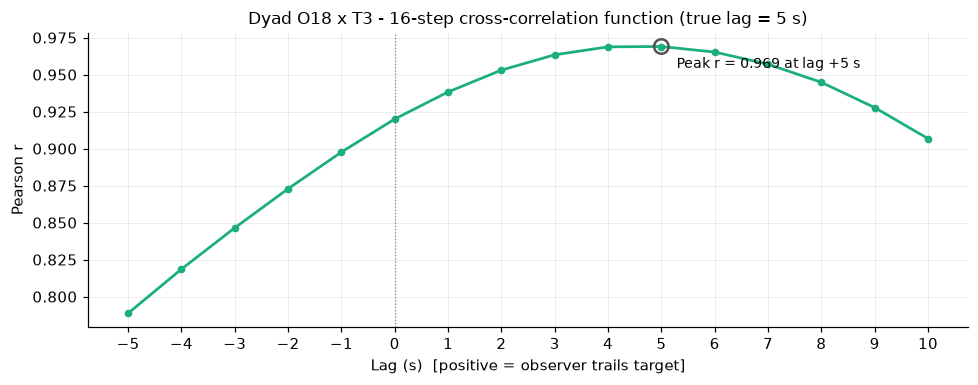

In [9]:
# --- Figure 2: the cross-correlation function for one dyad --------
ccf = all_lags.query("observer_id == 'O18' and target_id == 'T3'")
peak = ccf.loc[ccf["r"].abs().idxmax()]

fig, ax = plt.subplots()
ax.plot(ccf["lag_s"], ccf["r"], color=C_CONTROL, lw=1.8, marker="o", ms=4)
ax.scatter([peak["lag_s"]], [peak["r"]], s=90, zorder=3,
           facecolor="none", edgecolor=C_TARGET, lw=1.6)
ax.annotate(f"Peak r = {peak['r']:.3f} at lag {int(peak['lag_s']):+d} s",
            (peak["lag_s"], peak["r"]), textcoords="offset points",
            xytext=(10, -14), fontsize=9)
ax.axvline(0, color=C_TARGET, lw=0.8, ls=":", alpha=0.7)
ax.set(xlabel="Lag (s)  [positive = observer trails target]",
       ylabel="Pearson r", xticks=LAGS,
       title=f"Dyad O18 x T3 - 16-step cross-correlation function "
             f"(true lag = {profiles['O18']['true_lag']} s)")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 7. PEAK EXTRACTION + MASTER METRICS SHEET (exactly 168 rows)
# ============================================================
def summarise_session(g):
    peak = g.loc[g["r"].abs().idxmax()]        # maximum ABSOLUTE correlation
    return pd.Series({
        "Baseline Pearson r": g.loc[g["lag_s"] == 0, "r"].iloc[0],   # Tier 1
        "Peak r": peak["r"],                                          # Tier 2
        "Peak lag (s)": int(peak["lag_s"]),
    })

master = (all_lags.groupby(["observer_id", "target_id"])[["lag_s", "r"]]
          .apply(summarise_session)
          .reset_index()
          .merge(observers, on="observer_id")
          .merge(pd.DataFrame({"target_id": target_ids,
                               "Trial Length (s)": trial_lengths}),
                 on="target_id")
          .rename(columns={"observer_id": "Observer ID", "group": "Group",
                           "target_id": "Target ID"}))
master = (master[["Observer ID", "Group", "Target ID", "Trial Length (s)",
                  "Baseline Pearson r", "Peak r", "Peak lag (s)"]]
          .sort_values(["Observer ID", "Target ID"]).reset_index(drop=True))
master["Peak lag (s)"] = master["Peak lag (s)"].astype(int)

assert len(master) == 168, "brief requires exactly one row per observer-target pair"
master.to_csv(OUT_DIR / "master_metrics_sheet.csv", index=False)
master.head(12)

,Observer ID,Group,Target ID,Trial Length (s),Baseline Pearson r,Peak r,Peak lag (s)
0,O01,Test,T1,65,0.9904,0.9904,0
1,O01,Test,T2,107,0.9695,0.9888,1
2,O01,Test,T3,99,0.9803,0.9815,1
3,O01,Test,T4,86,0.9830,0.9878,1
4,O01,Test,T5,86,0.9906,0.9942,1
5,O01,Test,T6,112,0.9848,0.9851,1
6,O02,Test,T1,65,0.9666,0.9903,4
7,O02,Test,T2,107,0.8891,0.9870,3
8,O02,Test,T3,99,0.9680,0.9886,3
9,O02,Test,T4,86,0.9168,0.9912,3


In [11]:
# ============================================================
# 8. PIPELINE VALIDATION — recovers the known ground truth?
# ============================================================
truth = pd.read_csv("data/synthetic_ground_truth.csv",
                    index_col=0)["true_lag"]
recovered = (master.groupby("Observer ID")["Peak lag (s)"]
             .agg(lambda s: s.mode().iloc[0]))    # modal peak lag over 6 trials
check = pd.DataFrame({"injected lag": truth, "recovered lag": recovered})
err = (check["recovered lag"] - check["injected lag"]).abs()
print(f"injected lag recovered exactly     : {(err == 0).mean():.0%} of observers")
print(f"injected lag recovered within +-1 s: {(err <= 1).mean():.0%} of observers")
# NB: under heavy rating noise the peak can slip 1 s toward zero lag --
# expected behaviour for smooth, autocorrelated signals, not a pipeline bug.
check.T

injected lag recovered exactly     : 82% of observers
injected lag recovered within +-1 s: 100% of observers


,O01,O02,O03,O04,O05,O06,O07,O08,O09,O10,...,O19,O20,O21,O22,O23,O24,O25,O26,O27,O28
injected lag,1.0,3.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,3.0,...,4.0,6.0,7.0,6.0,4.0,4.0,4.0,7.0,6.0,4.0
recovered lag,1.0,3.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,3.0,...,3.0,5.0,7.0,6.0,4.0,4.0,4.0,6.0,6.0,4.0


## 9. Tier 3 — group-level comparative inferential analysis

**Mixed-Design ANOVA**: Group (between-subjects: Test vs. Control) × Target (within-subjects: 6 trials nested in each observer), run separately for:

1. **Tracking alignment strength** — Peak *r*, Fisher *z*-transformed first (standard practice before averaging or modelling correlation coefficients)
2. **Latency** — Peak lag in seconds

Main effects and the Group × Target interaction are reported with *F*-statistics, degrees of freedom, and exact *p*-values. A complementary **linear mixed-effects model** (random intercept per observer, respecting the nested repeated-measures design) is fitted as a robustness check.

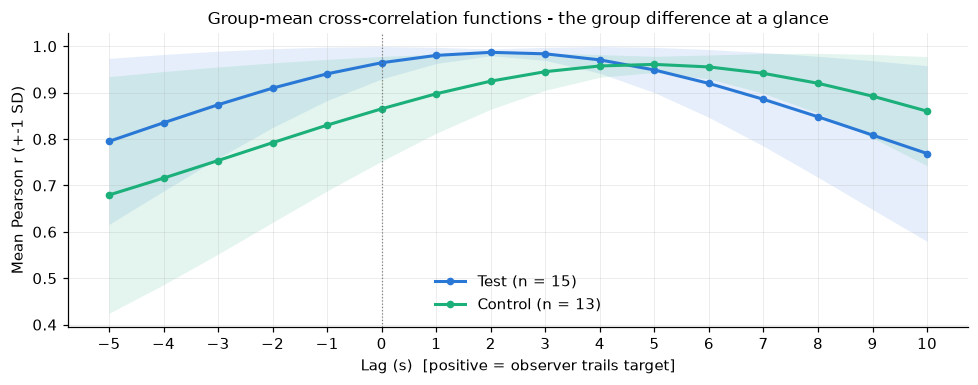

In [12]:
# --- Figure 3: group-mean cross-correlation functions -------------
grp_ccf = (all_lags.merge(observers, on="observer_id")
           .groupby(["group", "lag_s"])["r"].agg(["mean", "std"]).reset_index())

fig, ax = plt.subplots()
for grp, colour in [("Test", C_TEST), ("Control", C_CONTROL)]:
    g = grp_ccf[grp_ccf["group"] == grp]
    ax.plot(g["lag_s"], g["mean"], color=colour, lw=2, marker="o", ms=4,
            label=f"{grp} (n = {(observers['group'] == grp).sum()})")
    ax.fill_between(g["lag_s"], g["mean"] - g["std"], g["mean"] + g["std"],
                    color=colour, alpha=0.12, lw=0)
ax.axvline(0, color=C_TARGET, lw=0.8, ls=":", alpha=0.7)
ax.set(xlabel="Lag (s)  [positive = observer trails target]",
       ylabel="Mean Pearson r (+-1 SD)", xticks=LAGS,
       title="Group-mean cross-correlation functions - the group difference at a glance")
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 9a. MIXED-DESIGN ANOVA — Group (between) x Target (within)
# ============================================================
stats_df = master.rename(columns={"Observer ID": "observer", "Group": "group",
                                  "Target ID": "target"})
stats_df["z_peak_r"] = np.arctanh(stats_df["Peak r"])     # Fisher z

aov_align = pg.mixed_anova(data=stats_df, dv="z_peak_r",
                           within="target", between="group", subject="observer")
aov_lag = pg.mixed_anova(data=stats_df, dv="Peak lag (s)",
                         within="target", between="group", subject="observer")

# older pingouin versions name the p column "p-unc"; normalise it
aov_align = aov_align.rename(columns={"p-unc": "p_unc"})
aov_lag = aov_lag.rename(columns={"p-unc": "p_unc"})
print("Tracking alignment strength (Fisher-z Peak r):")
display(aov_align)
print("Latency (Peak lag, s):")
display(aov_lag)

Tracking alignment strength (Fisher-z Peak r):


,Source,SS,DF1,DF2,MS,F,p_unc,np2,eps
0,group,15.7773,1,26,15.7773,384.6398,4.1985e-17,0.9367,NaN
1,target,3.1593,5,130,0.6319,32.1169,3.3370e-21,0.5526,0.7961
2,Interaction,0.0713,5,130,0.0143,0.7249,6.0591e-01,0.0271,NaN


Latency (Peak lag, s):


,Source,SS,DF1,DF2,MS,F,p_unc,p_GG_corr,np2,eps,sphericity,W_spher,p_spher
0,group,308.8755,1,26,308.8755,54.5429,7.6577e-08,NaN,0.6772,NaN,NaN,NaN,NaN
1,target,8.1012,5,130,1.6202,3.0432,1.2452e-02,0.0593,0.1048,0.4733,False,0.0691,7.5392e-09
2,Interaction,8.8518,5,130,1.7704,3.3252,7.3670e-03,NaN,0.1134,NaN,NaN,NaN,NaN


In [14]:
# ============================================================
# 9b. COMPLEMENTARY LINEAR MIXED-EFFECTS MODEL (statsmodels)
# ============================================================
# Random intercept per observer handles the 6 trials nested within
# each observer (repeated measures).
lmm = smf.mixedlm("z_peak_r ~ group", stats_df,
                  groups=stats_df["observer"]).fit(reml=True)
print(lmm.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: z_peak_r
No. Observations:  168     Method:             REML    
No. Groups:        28      Scale:              0.0413  
Min. group size:   6       Log-Likelihood:     24.5543 
Max. group size:   6       Converged:          Yes     
Mean group size:   6.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     2.102    0.023 91.355 0.000  2.057  2.147
group[T.Test] 0.614    0.031 19.547 0.000  0.553  0.676
Group Var     0.000    0.010                           



/home/azureuser/observer-target-tracking-analysis/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
# ============================================================
# 10. APA-STYLE PUBLICATION-READY SUMMARY TABLES
# ============================================================
def apa_p(p):
    return "< .001" if p < 0.001 else ("= " + f"{p:.3f}".lstrip("0"))

def apa_anova_table(aov, dv_label):
    rows = []
    for _, r in aov.iterrows():
        rows.append({
            "DV": dv_label,
            "Effect": r["Source"],
            "F": round(r["F"], 2),
            "df": f"{int(r['DF1'])}, {int(r['DF2'])}",
            "p": apa_p(r["p_unc"]),
            "partial eta2": round(r["np2"], 3),
            "APA report": f"F({int(r['DF1'])}, {int(r['DF2'])}) = "
                          f"{r['F']:.2f}, p {apa_p(r['p_unc'])}",
        })
    return pd.DataFrame(rows)

apa_table = pd.concat([apa_anova_table(aov_align, "Alignment (Fisher-z Peak r)"),
                       apa_anova_table(aov_lag, "Latency (Peak lag, s)")],
                      ignore_index=True)
apa_table.to_csv(OUT_DIR / "anova_apa_table.csv", index=False)

descriptives = (master.groupby("Group")
                [["Baseline Pearson r", "Peak r", "Peak lag (s)"]]
                .agg(["mean", "std"]).round(3))
descriptives.to_csv(OUT_DIR / "group_descriptives.csv")

display(apa_table)
display(descriptives)

,DV,Effect,F,df,p,partial eta2,APA report
0,Alignment (Fisher-z Peak r),group,384.64,"1, 26",< .001,0.937,"F(1, 26) = 384.64, p < .001"
1,Alignment (Fisher-z Peak r),target,32.12,"5, 130",< .001,0.553,"F(5, 130) = 32.12, p < .001"
2,Alignment (Fisher-z Peak r),Interaction,0.72,"5, 130",= .606,0.027,"F(5, 130) = 0.72, p = .606"
3,"Latency (Peak lag, s)",group,54.54,"1, 26",< .001,0.677,"F(1, 26) = 54.54, p < .001"
4,"Latency (Peak lag, s)",target,3.04,"5, 130",= .012,0.105,"F(5, 130) = 3.04, p = .012"
5,"Latency (Peak lag, s)",Interaction,3.33,"5, 130",= .007,0.113,"F(5, 130) = 3.33, p = .007"


Baseline Pearson r        Peak r        Peak lag (s)       
                      mean    std   mean    std         mean    std
Group                                                              
Control              0.865  0.113  0.968  0.013        4.808  1.424
Test                 0.965  0.035  0.991  0.004        2.089  0.932

In [16]:
# ============================================================
# 11. TECHNICAL VERIFICATION (client re-runs; outputs must match)
# ============================================================
assert len(master) == 168                              # one row per dyad
assert len(all_lags) == 168 * 16 == 2688               # full lag grid
assert sorted(all_lags["lag_s"].unique()) == LAGS      # -5 ... +10, 1 s steps
assert master["Peak lag (s)"].between(-5, 10).all()
assert master.notna().all().all()                      # no missing cells

sheet_md5 = hashlib.md5(
    (OUT_DIR / "master_metrics_sheet.csv").read_bytes()).hexdigest()
print("All structural checks passed.")
print("master_metrics_sheet.csv MD5:", sheet_md5)
print("Re-running this notebook top-to-bottom reproduces this hash exactly.")

All structural checks passed.
master_metrics_sheet.csv MD5: eb1dc0dbb407555257cea84ddd4ebd7c
Re-running this notebook top-to-bottom reproduces this hash exactly.


## 12. Packaging & reproduction

The two companion deliverables are **auto-generated from this notebook** (never hand-written, so they can never diverge):

```bash
# mirror production script
jupyter nbconvert --to script tracking_crosscorr_analysis.ipynb

# environment manifest
pip freeze > requirements.txt   # (pinned versions committed alongside)
```

**To reproduce:** `pip install -r requirements.txt`, then *Run All*. The fixed seed (`RNG_SEED = 42`) makes every data frame — and the MD5 hash above — bit-identical on every run.

**To run on the real study data:** place the tracking files in `data/raw/`, adapt only the ingest cell (Section 4) to their file format, and skip Sections 3 & 8 (simulation and ground-truth validation). Tiers 1–3 run unchanged.

**Code, data, and outputs:** [github.com/mooceanstudio/observer-target-tracking-analysis](https://github.com/mooceanstudio/observer-target-tracking-analysis)

### References

- Mariooryad, S., & Busso, C. (2015). Correcting time-continuous emotional labels by modeling the reaction lag of evaluators. *IEEE Transactions on Affective Computing, 6*(2), 97–108.
- Khorram, S., McInnis, M., & Mower Provost, E. (2019). Jointly aligning and predicting continuous emotion annotations. *IEEE Transactions on Affective Computing.*
- Sharma, K., Castellini, C., van den Broek, E. L., Albu-Schaeffer, A., & Schwenker, F. (2019). A dataset of continuous affect annotations and physiological signals for emotion analysis (CASE). *Scientific Data, 6*, 196.